# Generate polycrystals for MOOSE

Notebook to generate polycrystals for MOOSE with the desired grain size, elongation, texture. It saves the grain structure into the format of EBSD data.

This jupyter notebook is being published with the following paper:

P.-C. A. Simon, L. K. Aagesen, C. Jiang, W. Jiang, J.-H. Ke, Multiscale calculation of the effective silver diffusion coefficient in polycrystalline silicon carbide: application to silver release in AGR-1 TRISO particles, Journal of Nuclear Materials, 563 (2022) 153669.
[https://doi.org/10.1016/j.jnucmat.2022.153669](https://doi.org/10.1016/j.jnucmat.2022.153669)

Contact: Pierre-Clément A. Simon - [pierreclement.simon@inl.gov](mailto:pierreclement.simon@inl.gov)

## Import

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits import mplot3d
from skimage import measure
import numpy as np
import math

In [2]:

def create_voronoi_polycrystal(domain_size, mesh_size, num_grain_vertically, num_grain_horizontally, expected_phase_fraction, domain_center_x = 0, domain_center_y = 0):

    ratio_elongation = num_grain_vertically/num_grain_horizontally # elongation ratio: x/y - 1 for equiaxed. - if ratio_elongation>1, then the grain are elongated horizontally
    # ======================= Generate the grain centroids ======================= #
    # Create a larger domain for elongation
    domain_size_elongation_x = domain_size / mesh_size
    domain_size_elongation_y = domain_size / mesh_size * ratio_elongation

    # Generate uniform base grid
    grain_diameter = domain_size_elongation_y / num_grain_vertically
    num_grain_y = num_grain_vertically
    num_grain_x = math.ceil(num_grain_vertically / ratio_elongation)
    grain_centroid_elongation_vect_y = grain_diameter * np.linspace(0.5, num_grain_y-0.5, num=num_grain_y)
    grain_centroid_elongation_vect_x = grain_diameter * np.linspace(0.5, num_grain_x-0.5, num=num_grain_x)

    # Generate random variations
    zeromat = np.zeros((num_grain_y,num_grain_x))
    randx = np.random.rand(num_grain_y,num_grain_x)*grain_diameter
    randy = np.random.rand(num_grain_y,num_grain_x)*grain_diameter

    # Derive grain centroids
    grain_centroid_elongated_mat_x_fix = np.zeros((num_grain_y,num_grain_x))
    grain_centroid_elongated_mat_y_fix =  np.zeros((num_grain_y,num_grain_x))
    grain_centroid_elongated_mat_x =  np.zeros((num_grain_y,num_grain_x))
    grain_centroid_elongated_mat_y =  np.zeros((num_grain_y,num_grain_x))

    for i in range(num_grain_x):
        grain_centroid_elongated_mat_x_fix[:,i] = grain_centroid_elongation_vect_x[i] + zeromat[:,i]
        grain_centroid_elongated_mat_x[:,i] = grain_centroid_elongation_vect_x[i] + randx[:,i]

    for j in range(num_grain_y):
        grain_centroid_elongated_mat_y_fix[j,:] = grain_centroid_elongation_vect_y[j] + zeromat[j,:]
        grain_centroid_elongated_mat_y[j,:] = grain_centroid_elongation_vect_y[j] + randy[j,:]

    # transform grain_centroid_elongated_mat_x and grain_centroid_elongated_mat_y into 1-dim arrays
    grain_centroid_elongated_vect_long_x = np.array([])
    grain_centroid_elongated_vect_long_y = np.array([])
    for i in range(len(grain_centroid_elongated_mat_x)):
        grain_centroid_elongated_vect_long_x = np.append(grain_centroid_elongated_vect_long_x,grain_centroid_elongated_mat_x[i])
        grain_centroid_elongated_vect_long_y = np.append(grain_centroid_elongated_vect_long_y,grain_centroid_elongated_mat_y[i])

    # randomize grain indices (for the plots below)
    perm = np.random.permutation(num_grain_y*num_grain_x)
    grain_centroid_elongated_vect_long_perm_x = np.zeros((num_grain_y*num_grain_x))
    grain_centroid_elongated_vect_long_perm_y = np.zeros((num_grain_y*num_grain_x))
    for i in range(num_grain_y*num_grain_x):
            grain_centroid_elongated_vect_long_perm_x[perm[i]] = grain_centroid_elongated_vect_long_x[i]
            grain_centroid_elongated_vect_long_perm_y[perm[i]] = grain_centroid_elongated_vect_long_y[i]

    print("The number of centroids is equal to: ", num_grain_y*num_grain_x)


    # ============================ Voronoi tesselation =========================== #
    # Initialization
    grain_structure_elongation = np.zeros((int(round(domain_size_elongation_y/ratio_elongation)+1),int(domain_size_elongation_x)+1)) # Indice of the grain at a given position
    position_x = np.zeros((int(domain_size_elongation_x))+1) # position along x
    position_y = np.zeros((int(round(domain_size_elongation_y/ratio_elongation)))+1) # position along y

    # Voronoi tesselation
    for i in range(round(domain_size_elongation_y/ratio_elongation)+1):
        position_y[i] = i*ratio_elongation
        for j in range(int(domain_size_elongation_x)+1):
            position_x[j] = j
            dist_vect = np.zeros((num_grain_x*num_grain_y,1))
            for q in range(num_grain_x*num_grain_y):
                # derive length along x
                dist_x =  j-grain_centroid_elongated_vect_long_perm_x[q]
                if abs(dist_x) > domain_size_elongation_x/2:
                    if dist_x > 0:
                        dist_x =  j-domain_size_elongation_x-grain_centroid_elongated_vect_long_perm_x[q]
                    else:
                        dist_x =  j+domain_size_elongation_x-grain_centroid_elongated_vect_long_perm_x[q]
                # derive length along y
                dist_y =  i*ratio_elongation-grain_centroid_elongated_vect_long_perm_y[q]
                if abs(dist_y) > domain_size_elongation_y/2:
                    if dist_y > 0:
                        dist_y =  i*ratio_elongation-domain_size_elongation_y-grain_centroid_elongated_vect_long_perm_y[q]
                    else:
                        dist_y =  i*ratio_elongation+domain_size_elongation_y-grain_centroid_elongated_vect_long_perm_y[q]

                dist_vect[q] = math.sqrt(dist_x*dist_x + dist_y*dist_y)

            min_dist_ind =  np.where(dist_vect == dist_vect.min())[0]
            grain_structure_elongation[i,j] = min_dist_ind[0]

    # =================== number of grains without periodic BC =================== #

    # initialize
    num_grains_actual = 0
    binary_matrix_single_grain = np.zeros((len(grain_structure_elongation),len(grain_structure_elongation[0])))

    for i in range(int(np.amin(grain_structure_elongation)),int(np.amax(grain_structure_elongation))):
        binary_matrix_single_grain[grain_structure_elongation==i] = 1
        all_labels = measure.label(binary_matrix_single_grain)
        num_grains_actual = num_grains_actual + np.amax(all_labels)
        binary_matrix_single_grain[grain_structure_elongation==i] = 0

    print('The number of grains in the microstructure (without periodicity) is equal to', num_grains_actual)

    # ==================== list the grain id at each position ==================== #

    # rescale for elongation and mesh size
    position_x_mesh = position_x * mesh_size
    position_y_mesh = position_y * mesh_size / ratio_elongation
    position_y_mesh = position_y_mesh - np.amin(position_y_mesh)

    #  center mesh
    domain_min_x = domain_center_x - domain_size/2
    domain_min_y = domain_center_y - domain_size/2
    domain_max_x = domain_center_x + domain_size/2
    domain_max_y = domain_center_y + domain_size/2
    position_x_mesh = position_x_mesh + domain_min_x - mesh_size/2
    position_y_mesh = position_y_mesh + domain_min_y - mesh_size/2

    # create verctors with the 2-dimensional arrays
    position_x_vect = np.zeros(len(position_x_mesh)**2)
    position_y_vect = np.zeros(len(position_x_mesh)**2)
    grain_structure_vect = np.zeros(len(position_x_mesh)**2)-1
    position_x_final = np.array([])
    position_y_final = np.array([])
    grain_structure_final = np.array([])

    for i in range(len(position_y_mesh)):
        if (position_y_mesh[i]>domain_min_y) and (position_y_mesh[i]<domain_max_y):
            for j in range(len(position_x_mesh)):
                k = i+j*len(position_y_mesh)-1*len(position_y_mesh)
                if (position_x_mesh[j]>domain_min_x) and (position_x_mesh[j]<domain_max_x):
                    position_x_vect[k] = position_x_mesh[j]
                    position_y_vect[k] = position_y_mesh[i]
                    grain_structure_vect[k] = grain_structure_elongation[i,j]

                if not(np.isnan(position_x_vect[k])) and (grain_structure_vect[k]!=-1):
                    position_x_final = np.append(position_x_final,position_x_vect[k])
                    position_y_final = np.append(position_y_final,position_y_vect[k])
                    grain_structure_final = np.append(grain_structure_final,grain_structure_vect[k])

    num_grains_actual_final = len(np.unique(grain_structure_final))
    print('The original number of unique grains was equal to:', num_grain_y*num_grain_x)
    print('The number of unique grains is equal to:', num_grains_actual_final)


    # derive x_step and y_step (should be the same than mesh_size)
    position_x_vect_test = np.unique(position_x_final)
    x_step = position_x_vect_test[1]-position_x_vect_test[0]
    position_y_vect_test = np.unique(position_y_final)
    y_step = position_y_vect_test[2]-position_y_vect_test[1]

    if (x_step==y_step) and (x_step==mesh_size):
        print('test: All is good with mesh size and steps in x and y directions')
    else:
        print('Error with mesh size and steps in x and y directions. x_step = ', x_step, ', y_step = ', y_step, 'and mesh_size = ',mesh_size)

    # =========================== Generate Euler Angles ========================== #

    # generate euler angle
    angle_deg_3params = np.zeros((num_grains_actual, 3))
    angle_deg_3params[:,0] = np.random.uniform(0, 2*np.pi, num_grains_actual)
    angle_deg_3params[:,1] = np.random.uniform(0, np.pi, num_grains_actual)
    angle_deg_3params[:,2] = np.random.uniform(0, 2*np.pi, num_grains_actual)

    # generate phase number
    random_values = np.random.rand(num_grains_actual)
    phase_index = np.where(random_values < expected_phase_fraction, 1, 2)
    # phase_index = np.random.choice([1, 2], size=num_grains_actual)

    # ================================ get fraction ============================== #
    grain_structure_final_copy = np.copy(grain_structure_final)
    grain_structure_final_copy.resize(int(domain_size_elongation_x),int(domain_size_elongation_y))
    poly_outline = np.flipud(grain_structure_final_copy)
    phase_outline = np.zeros(poly_outline.shape)
    for index, phase_ind in enumerate(phase_index):
        phase_outline += (phase_ind == 1) * (poly_outline == index)
    phase_fraction = np.sum(phase_outline == 1) / np.sum(phase_outline != -1)

    EBSD_data = [num_grains_actual_final, domain_min_x, domain_max_x, x_step, position_x_final, domain_min_y, domain_max_y, y_step, position_y_final, angle_deg_3params, grain_structure_final, phase_index, phase_fraction]

    return EBSD_data

## Initialize Input parameters

The number of centroids is equal to:  16
The number of grains in the microstructure (without periodicity) is equal to 24
The original number of unique grains was equal to: 16
The number of unique grains is equal to: 16
test: All is good with mesh size and steps in x and y directions
>>>> phase 1 fraction = 0.185
The number of centroids is equal to:  16
The number of grains in the microstructure (without periodicity) is equal to 24
The original number of unique grains was equal to: 16
The number of unique grains is equal to: 16
test: All is good with mesh size and steps in x and y directions
>>>> phase 1 fraction = 0.24
The number of centroids is equal to:  16
The number of grains in the microstructure (without periodicity) is equal to 26
The original number of unique grains was equal to: 16
The number of unique grains is equal to: 16
test: All is good with mesh size and steps in x and y directions
>>>> phase 1 fraction = 0.2275
The number of centroids is equal to:  16
The number of gra

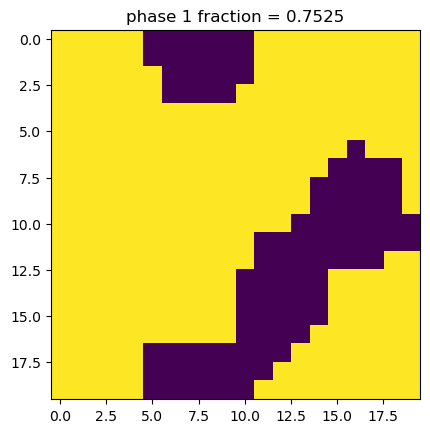

In [6]:
# Basic domain and grain size parameters
domain_size = 1000 # square domain size
num_grain_vertically = 4
num_grain_horizontally = 4

mesh_size = 50
domain_center_x = 0
domain_center_y = 0

# Prepare file names
filename_base = f"../EBSD_files/Polycrystal_Domain_{domain_size}_NumGrainHor_{num_grain_horizontally}_NumGrainVert_{num_grain_vertically}"


expected_fraction = [0.25, 0.75]
threshold_fraction = 0.01
phase_fraction = 0

for i in range(len(expected_fraction)):
    while abs(phase_fraction - expected_fraction[i]) > threshold_fraction:
        [num_grains_actual_final, domain_min_x, domain_max_x, x_step, position_x_final, domain_min_y, domain_max_y, y_step, position_y_final, angle_deg_3params, grain_structure_final, phase_index, phase_fraction] = \
            create_voronoi_polycrystal(domain_size, mesh_size, num_grain_vertically, num_grain_horizontally, expected_fraction[i])

        print(f">>>> phase 1 fraction = {phase_fraction}")

    # ================================ plot figure =============================== #
    ratio_elongation = num_grain_vertically/num_grain_horizontally
    grain_structure_final_copy = np.copy(grain_structure_final)
    grain_structure_final_copy.resize(int(domain_size / mesh_size),int(domain_size / mesh_size * ratio_elongation))
    poly_outline = np.flipud(grain_structure_final_copy)
    plt.imshow(poly_outline)
    plt.savefig(f"{filename_base}_PF0{int(expected_fraction[i]*100)}_microstructure.png", bbox_inches='tight', dpi=300)

    phase_outline = np.zeros(poly_outline.shape)
    for index, phase_ind in enumerate(phase_index):
        phase_outline += (phase_ind == 1) * (poly_outline == index)
    plt.imshow(phase_outline)
    phase_fraction = np.sum(phase_outline == 1) / np.sum(phase_outline != -1)
    plt.title(f"phase 1 fraction = {phase_fraction}")
    plt.savefig(f"{filename_base}_PF0{int(expected_fraction[i]*100)}_phase_structure.png", bbox_inches='tight', dpi=300)

    # ================================= save EBSD ================================ #

    filename_EBSD = f"{filename_base}_PF0{int(expected_fraction[i]*100)}.txt"
    fileEBSD = open(filename_EBSD,"w")
    L = ['# Header:    Marmot Input File \n',
        '# Date:      24-May-2021 00:23:55\n',
        '# \n',
        '# Column 1:  Euler angle "phi1" (in radians)\n',
        '# Column 2:  Euler angle "PHI" (in radians)\n',
        '# Column 3:  Euler angle "phi2" (in radians)\n',
        '# Column 4:  x-coordinate (in nm)\n',
        '# Column 5:  y-coordinate (in nm)\n',
        '# Column 6:  z-coordinate (in nm)\n',
        '# Column 7:  grain number (integer)\n',
        '# Column 8:  phase number (integer)\n',
        '# Column 9:  symmetry class (from TSL)\n',
        '#\n',
        '# Phase 1:   Li2O (symmetry class = 225)\n',
        f'# Number of Grains in Phase 1:  {num_grains_actual_final}\n',
        '#\n',
        f'# X_Min:      {domain_min_x}\n',
        f'# X_Max:      {domain_max_x}\n',
        f'# X_step:     {x_step}\n',
        f'# X_Dim:      {len(np.unique(position_x_final))}\n',
        '#\n',
        f'# Y_Min:      {domain_min_y}\n',
        f'# Y_Max:      {domain_max_y}\n',
        f'# Y_step:     {y_step}\n',
        f'# Y_Dim:      {len(np.unique(position_y_final))}\n',
        '#\n',
        '# Z_Min:      0.000000\n',
        '# Z_Max:      0.000000\n',
        '# Z_step:     0.000000\n',
        '# Z_Dim:      0\n',
        '#\n']
    fileEBSD.writelines(L)

    for i in range(len(position_x_final)):
        L = f"{angle_deg_3params[int(grain_structure_final[i]),0]:.5f} "\
            f"{angle_deg_3params[int(grain_structure_final[i]),1]:.5f} "\
            f"{angle_deg_3params[int(grain_structure_final[i]),2]:.5f} "\
            f"{position_x_final[i]:.5f} {position_y_final[i]:.5f} "\
            f"0.00000 {int(grain_structure_final[i]):>3} {phase_index[int(grain_structure_final[i])]} {225} \n"
        fileEBSD.write(L)

    fileEBSD.close()

